In [3]:
import os
import json
import pickle
from copy import deepcopy
from typing import List, Dict, Any
from collections import namedtuple

import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import (
    Polygon, MultiPolygon, LineString, MultiLineString, Point, GeometryCollection, shape
)
from shapely.geometry import mapping as shp_mapping
from shapely.ops import unary_union
from shapely.strtree import STRtree

import resplan_utils as R

# ---- paths (use your actual pkl name) ----
DATA_PKL     = "ResPlan.pkl"
OUT_JSON_DIR = "resplan_json"
OUT_PLOT_DIR = "resplan_plot"

os.makedirs(OUT_JSON_DIR, exist_ok=True)
os.makedirs(OUT_PLOT_DIR,  exist_ok=True)

# ---- categories ----
ROOM_KEYS  = ["bedroom","bathroom","kitchen","living","balcony","storage","stair","veranda","parking"]
STRUCT_KEYS = ["interior_wall","exterior_wall","door","window","front_door"]
GEOM_LAYERS = ["inner","garden","land","pool"]
META_KEYS   = ["id","unitType","area","net_area","wall_depth"]

# ---- colors ----
ROOM_COLORS = {
    "living":   "#d9d9d9",
    "bedroom":  "#66c2a5",
    "bathroom": "#fc8d62",
    "kitchen":  "#8da0cb",
    "balcony":  "#b3b3b3",
    "storage":  "#cccccc",
    "stair":    "#aaaaaa",
    "veranda":  "#bbbbbb",
    "parking":  "#dddddd",
}
STRUCT_COLORS = {
    "interior_wall": "#445DFF",  
    "exterior_wall": "#FFD344",  
    "door":          "#e78ac3",
    "window":        "#a6d854",
    "front_door":    "#a63603",
}

# Numerical tolerances (meters)
EPS_LEN = 0.02  # ~2 cm for length tests
EPS_AREA = 0.01  # ~1e-2 m²
WALL_BUFFER = 0.02  # buffer wall centerlines if walls are given as lines
OPENING_BUFFER = 0.005  # 5 mm to robustify tiny gaps

# Utility: safe float
def _f(x, nd=6):
    try: 
        return round(float(x), nd)
    except: 
        return x

# Data structure for geometric records
GeoRec = namedtuple("GeoRec", "id cls subtype level geom raw")

In [4]:
def geojsonify(geom):
    if geom is None:
        return {"type": "GeometryCollection", "geometries": []}
    if isinstance(geom, (Polygon, MultiPolygon, LineString, MultiLineString, Point)):
        return {"type": "GeometryCollection", "geometries": []} if geom.is_empty else shp_mapping(geom)
    parts = [g for g in R.get_geometries(geom)]
    if not parts:
        return {"type": "GeometryCollection", "geometries": []}
    if all(isinstance(g, Polygon) for g in parts):
        return {"type": "MultiPolygon", "coordinates": [shp_mapping(g)["coordinates"] for g in parts]}
    return {"type": "GeometryCollection", "geometries": [shp_mapping(g) for g in parts]}

def bbox_of_geom(geom):
    if geom is None or getattr(geom, "is_empty", True):
        return [None, None, None, None]
    x1, y1, x2, y2 = geom.bounds
    return [float(x1), float(y1), float(x2), float(y2)]

def assign_ids(n, prefix):
    return [f"{prefix}-{i:04d}" for i in range(1, n+1)]

def find_instances(plan):
    """Extract instances from JSON structure"""
    inst = {"rooms": [], "walls": [], "openings": []}
    
    if "instances" in plan:
        # Extract rooms
        if "room" in plan["instances"]:
            room_data = plan["instances"]["room"]
            for room_type, room_list in room_data.items():
                for room in room_list:
                    inst["rooms"].append(room)
        
        # Extract structural elements  
        if "structural" in plan["instances"]:
            struct_data = plan["instances"]["structural"]
            
            # Walls
            for wall_type in ["interior_wall", "exterior_wall"]:
                if wall_type in struct_data:
                    for wall in struct_data[wall_type]:
                        w = deepcopy(wall)
                        w.setdefault("subtype", "exterior" if "exterior" in wall_type else "interior")
                        inst["walls"].append(w)
            
            # Openings (doors and windows)
            for opening_type in ["door", "window", "front_door"]:
                if opening_type in struct_data:
                    for opening in struct_data[opening_type]:
                        o = deepcopy(opening)
                        o.setdefault("subtype", opening_type)
                        inst["openings"].append(o)
    
    return inst

def _geom(obj):
    """Return shapely geometry from geom field"""
    if obj is None: 
        return None
    g = obj.get("geom") if isinstance(obj, dict) else None
    if isinstance(g, dict) and "type" in g:
        return shape(g)
    return None

def _id(obj, fallback_prefix):
    """Return ID from object"""
    if isinstance(obj, dict) and "id" in obj:
        return str(obj["id"])
    return f"{fallback_prefix}-{abs(hash(str(obj)))%10**8:08d}"

def _level(obj):
    """Extract level/storey information"""
    return obj.get("level") or obj.get("storey") or obj.get("props", {}).get("level")

In [5]:
# add this mapping once
ROOM_PREFIX = {
    "bathroom": "BTH",
    "balcony":  "BAL",
    "bedroom":  "BED",
    "living":   "LIV",
    "kitchen":  "KIT",
    "corridor": "COR",
    "hall":     "HAL",
    "storage":  "STR",
    "toilet":   "WC",
    "dining":   "DIN",
    "study":    "STD",
    "laundry":  "LDY",
}

# minimal helpers to update references
def _update_rel_table(tbl, slots, remap):
    if not isinstance(tbl, list): return
    for e in tbl:
        for slot in slots:
            if slot == "rooms" and isinstance(e.get(slot), list):
                e[slot] = [remap.get(x, x) for x in e[slot]]
            else:
                v = e.get(slot)
                if v in remap: e[slot] = remap[v]

def _apply_room_id_remap(plan, remap):
    # relations (top-level)
    rel = plan.get("relations")
    if isinstance(rel, dict):
        _update_rel_table(rel.get("bounded_by"),            ["room"],       remap)
        _update_rel_table(rel.get("adjacent_to"),           ["a","b"],      remap)
        _update_rel_table(rel.get("connected_via_door"),    ["rooms"],      remap)
        _update_rel_table(rel.get("window_connects"),       ["from","to"],  remap)
        _update_rel_table(rel.get("contains"),              ["container"],  remap)
    # graph.relations (if present)
    grel = plan.get("graph", {}).get("relations")
    if isinstance(grel, dict):
        _update_rel_table(grel.get("bounded_by"),           ["room"],       remap)
        _update_rel_table(grel.get("adjacent_to"),          ["a","b"],      remap)
        _update_rel_table(grel.get("connected_via_door"),   ["rooms"],      remap)
        _update_rel_table(grel.get("window_connects"),      ["from","to"],  remap)
        _update_rel_table(grel.get("contains"),             ["container"],  remap)

def relabel_rooms_with_subtype_prefixes_inplace(plan):
    """
    Reassigns room IDs by subtype using subtype-specific prefixes,
    reusing your existing assign_ids() to build the sequences.
    Updates all relation references.
    """
    inst = plan.get("instances", {})
    remap = {}

    # Layout: instances.room is a dict {subtype: [room, ...]}
    room_dict = inst.get("room")
    if isinstance(room_dict, dict):
        for subtype, arr in room_dict.items():
            pref = ROOM_PREFIX.get(subtype.lower(), "RM")
            new_ids = assign_ids(len(arr), pref)
            for i, rec in enumerate(arr):
                old = rec.get("id")
                new = new_ids[i]
                if old and old != new:
                    remap[old] = new
                    rec["id"] = new
    # Alternative layout: instances.rooms is a flat list with rec["subtype"]
    elif isinstance(inst.get("rooms"), list):
        # group by subtype to keep numbering compact per subtype
        by_sub = {}
        for rec in inst["rooms"]:
            st = (rec.get("subtype") or "unknown").lower()
            by_sub.setdefault(st, []).append(rec)
        for subtype, arr in by_sub.items():
            pref = ROOM_PREFIX.get(subtype, "RM")
            new_ids = assign_ids(len(arr), pref)
            for i, rec in enumerate(arr):
                old = rec.get("id")
                new = new_ids[i]
                if old and old != new:
                    remap[old] = new
                    rec["id"] = new
    else:
        # Legacy top-level "rooms"/"room"
        for key in ("rooms","room"):
            if isinstance(plan.get(key), list):
                by_sub = {}
                for rec in plan[key]:
                    st = (rec.get("subtype") or "unknown").lower()
                    by_sub.setdefault(st, []).append(rec)
                for subtype, arr in by_sub.items():
                    pref = ROOM_PREFIX.get(subtype, "RM")
                    new_ids = assign_ids(len(arr), pref)
                    for i, rec in enumerate(arr):
                        old = rec.get("id")
                        new = new_ids[i]
                        if old and old != new:
                            remap[old] = new
                            rec["id"] = new

    if remap:
        _apply_room_id_remap(plan, remap)
    return remap

In [6]:
def index_instances(plan):
    """Create indexed geometry lists with spatial trees"""
    inst = find_instances(plan)
    rooms, walls, openings = [], [], []
    
    for r in inst["rooms"]:
        g = _geom(r)
        if g is None or g.is_empty: 
            continue
        rooms.append(GeoRec(_id(r, "RM"), "Room", r.get("subtype"), _level(r), g, r))
        
    for w in inst["walls"]:
        g = _geom(w)  
        if g is None or g.is_empty: 
            continue
        walls.append(GeoRec(_id(w, "WL"), "Wall", w.get("subtype"), _level(w), g, w))
        
    for o in inst["openings"]:
        g = _geom(o)
        if g is None or g.is_empty: 
            continue
        openings.append(GeoRec(_id(o, "OP"), "Opening", o.get("subtype"), _level(o), g, o))
        
    
    idx = {
        "rooms": rooms,
        "walls": walls, 
        "openings": openings,
        "tree": {
            "rooms": STRtree([x.geom for x in rooms]) if rooms else None,
            "walls": STRtree([x.geom for x in walls]) if walls else None,
            "openings": STRtree([x.geom for x in openings]) if openings else None,
        }
    }
    return idx

def boundary_overlap_length(room_poly: Polygon, wall_geom) -> float:
    """Calculate overlap length between room boundary and wall geometry"""
    if isinstance(wall_geom, (LineString, MultiLineString)):
        buf = wall_geom.buffer(WALL_BUFFER, cap_style=2, join_style=2)
        inter = room_poly.boundary.intersection(buf)
    else:
        inter = room_poly.boundary.intersection(wall_geom)
    
    if inter.is_empty: 
        return 0.0
    try:
        return _f(inter.length)
    except Exception:
        if hasattr(inter, "geoms"):
            return _f(sum(g.length for g in inter.geoms))
        return 0.0

def opening_on_wall(opening_geom, wall_geom) -> bool:
    """Check if opening is positioned on wall"""
    a = opening_geom
    b = wall_geom
    if isinstance(b, (LineString, MultiLineString)):
        b = b.buffer(WALL_BUFFER, cap_style=2, join_style=2)
    return a.buffer(OPENING_BUFFER).intersects(b)

def room_contains(geom_room: Polygon, geom_obj) -> bool:
    """Check if room contains an object with tolerance"""
    return geom_room.buffer(EPS_LEN).contains(geom_obj)

In [7]:
def compute_relations(plan):
    """Compute architectural relationships between plan elements"""
    idx = index_instances(plan)
    
    rooms = idx["rooms"]
    walls = idx["walls"] 
    openings = idx["openings"]
    
    print(f"Found {len(rooms)} rooms, {len(walls)} walls, {len(openings)} openings")
    
    # Build maps for quick reverse lookup
    id2room = {r.id: r for r in rooms}
    
    # --- bounded_by (Room -> WallSegment) ---
    bounded_by = []
    bounded_by_summary = {}  # Room -> list of walls
    
    for r in rooms:
        room_walls = []
        cand = walls if idx["tree"]["walls"] is None else [
            walls[i] for i in idx["tree"]["walls"].query(r.geom)
            if i < len(walls)
        ]
        for w in cand:
            olap = boundary_overlap_length(r.geom, w.geom)
            if olap >= EPS_LEN:
                bounded_by.append({
                    "id": f"E-bnd-{len(bounded_by)+1:05d}",
                    "room": r.id, "wall": w.id, "length": olap,
                    "wall_type": w.subtype or "unknown"
                })
                room_walls.append(w.id)
        
        if room_walls:
            bounded_by_summary[r.id] = room_walls
    
    # --- adjacent_to (Room <-> Room) ---
    adjacent_to = []
    seen_pairs = set()
    for i, ri in enumerate(rooms):
        for rj in rooms[i+1:]:
            inter = ri.geom.buffer(0).boundary.intersection(rj.geom.buffer(0).boundary)
            shared_len = _f(inter.length) if not inter.is_empty else 0.0
            if shared_len >= EPS_LEN:
                key = tuple(sorted((ri.id, rj.id)))
                if key not in seen_pairs:
                    seen_pairs.add(key)
                    adjacent_to.append({
                        "id": f"E-adj-{len(adjacent_to)+1:05d}",
                        "a": ri.id, "b": rj.id, "overlap_length": shared_len
                    })
    
    # --- hosts_opening (Wall -> Opening) - Allow multiple walls per opening ---
    hosts_opening = []
    opening_wall_map = {}  # opening_id -> list of wall_ids
    
    for op in openings:
        hosting_walls = []
        cand = walls if idx["tree"]["walls"] is None else [
            walls[i] for i in idx["tree"]["walls"].query(op.geom)
            if i < len(walls)
        ]
        
        for w in cand:
            if opening_on_wall(op.geom, w.geom):
                hosts_opening.append({
                    "id": f"E-host-{len(hosts_opening)+1:05d}",
                    "wall": w.id,
                    "opening": op.id, 
                    "opening_type": op.subtype or "opening"
                })
                hosting_walls.append(w.id)
        
        if hosting_walls:
            opening_wall_map[op.id] = hosting_walls
    
    # helper: map wall -> rooms that bound it
    wall_to_rooms = {}
    for e in bounded_by:
        wall_to_rooms.setdefault(e["wall"], set()).add(e["room"])
    
# --- connected_via_door (simplified fix) ---
    connected_via_door = []

    # Create a map of door_id -> all walls that host it
    door_to_walls = {}
    for e in hosts_opening:
        if e.get("opening_type") in ["door", "front_door"]:
            door_id = e["opening"]
            if door_id not in door_to_walls:
                door_to_walls[door_id] = []
            door_to_walls[door_id].append(e["wall"])

    print(f"\nDEBUG: Door to walls mapping:")
    for door_id, wall_list in door_to_walls.items():
        print(f"  {door_id} -> {wall_list}")

    # Process each unique door
    for door_id, hosting_walls in door_to_walls.items():
        # Get the door type from hosts_opening
        door_type = None
        for e in hosts_opening:
            if e["opening"] == door_id:
                door_type = e.get("opening_type")
                break
        
        # Collect all rooms connected to any wall that hosts this door
        connected_rooms = set()
        for wall_id in hosting_walls:
            connected_rooms.update(wall_to_rooms.get(wall_id, []))
        
        rooms_list = sorted(list(connected_rooms))
        print(f"  {door_id} ({door_type}) connects rooms: {rooms_list}")
        
        if door_type == "front_door":
            # For front door, specifically target living room
            target_room = "LI-0001"  # Default to living room
            if "LI-0001" in rooms_list:
                target_room = "LI-0001"
            elif rooms_list:
                # Fallback to first room if living room not found
                target_room = rooms_list[0]
                
            connected_via_door.append({
                "id": f"E-pass-{len(connected_via_door)+1:05d}",
                "door": door_id,
                "door_type": "front_door",
                "rooms": [target_room, "OUT-0000"]
            })
            
        elif door_type == "door":
            if len(rooms_list) == 2:
                # Interior door connecting two rooms
                connected_via_door.append({
                    "id": f"E-pass-{len(connected_via_door)+1:05d}",
                    "door": door_id,
                    "door_type": "door",
                    "rooms": rooms_list
                })
            elif len(rooms_list) == 1:
                # Door to outside
                connected_via_door.append({
                    "id": f"E-pass-{len(connected_via_door)+1:05d}",
                    "door": door_id,
                    "door_type": "door", 
                    "rooms": [rooms_list[0], "OUT-0000"]
                })
            elif len(rooms_list) == 0:
                print(f"    WARNING: Door {door_id} has no associated rooms")
    
    print(f"Computed relationships:")
    print(f"  - bounded_by: {len(bounded_by)} (grouped by {len(bounded_by_summary)} rooms)")
    print(f"  - adjacent_to: {len(adjacent_to)}")
    print(f"  - hosts_opening: {len(hosts_opening)}")
    print(f"  - connected_via_door: {len(connected_via_door)}")
    
    # Print bounded_by summary
    if bounded_by_summary:
        print(f"\nBounded-by Summary:")
        for room_id, wall_list in bounded_by_summary.items():
            print(f"  {room_id}: {', '.join(wall_list)}")
    
    rel = {
        "bounded_by": bounded_by,
        "bounded_by_summary": bounded_by_summary,
        "adjacent_to": adjacent_to, 
        "hosts_opening": hosts_opening,
        "connected_via_door": connected_via_door,
    }
    return rel

In [8]:
def extract_room_instances(plan: Dict[str, Any]) -> Dict[str, list]:
    out = {k: [] for k in ROOM_KEYS}
    for rk in ROOM_KEYS:
        geom = plan.get(rk)
        if geom is None:
            continue
        geoms = []
        if hasattr(geom, "geoms"):          # MultiPolygon
            geoms = list(geom.geoms)
        elif hasattr(geom, "__iter__"):     # iterable of geometries
            for g in geom:
                if hasattr(g, "geoms"):
                    geoms.extend(list(g.geoms))
                else:
                    geoms.append(g)
        else:
            geoms = [geom]
        geoms = [g for g in geoms if not getattr(g, "is_empty", True)]

        ids = assign_ids(len(geoms), rk[:2].upper())
        for _id, g in zip(ids, geoms):
            c = getattr(g, "centroid", None)
            centroid = (float(c.x), float(c.y)) if c is not None and not g.is_empty else (None, None)
            out[rk].append({
                "id": _id,
                "type": rk,
                "geom": geojsonify(g),
                "props": {
                    "area": float(getattr(g, "area", 0.0)),
                    "centroid": centroid,
                    "bbox": bbox_of_geom(g),
                }
            })
    return out

def _walls_as_polygons(plan, fallback_frac=0.01):
    """Union of wall polygons; buffer lines a tiny amount so ops are area-vs-area."""
    W = R.get_plan_width(plan) or 1.0
    bufw = fallback_frac * W
    polys = []
    for g in R.get_geometries(plan.get("wall")):
        if isinstance(g, (Polygon, MultiPolygon)):
            polys += [g] if isinstance(g, Polygon) else list(g.geoms)
        elif isinstance(g, (LineString, MultiLineString)):
            polys.append(g.buffer(bufw, join_style=2, cap_style=2))
    return unary_union(polys).buffer(0)

def _instances_from_geom(category: str, geom) -> list:
    """Convert Polygon/MultiPolygon to our instance schema."""
    if geom is None or geom.is_empty:
        return []
    polys = list(geom.geoms) if isinstance(geom, MultiPolygon) else [geom]
    ids = assign_ids(len(polys), category[:2].upper())
    out = []
    for _id, p in zip(ids, polys):
        c = p.centroid
        out.append({
            "id": _id,
            "type": category,
            "geom": geojsonify(p),
            "props": {
                "area": float(p.area),
                "centroid": (float(c.x), float(c.y)),
                "bbox": bbox_of_geom(p),
            }
        })
    return out

def split_walls(plan: Dict[str, Any],
                band_factor: float = 1.5,
                band_min_frac: float = 0.02,
                fallback_frac: float = 0.01) -> Dict[str, list]:
    """Return structural instances dict using distance-to-boundary band."""
    p = R.normalize_keys(plan.copy())
    inner = p["inner"]
    if inner.geom_type == "MultiPolygon":
        inner = max(inner.geoms, key=lambda g: g.area)

    W = R.get_plan_width(p) or 1.0
    t = float(p.get("wall_width", 4.0) or 4.0)
    band_hw = max(band_factor * t, band_min_frac * W)

    walls_poly   = _walls_as_polygons(p, fallback_frac=fallback_frac)
    boundary_band = inner.boundary.buffer(band_hw, join_style=2, cap_style=2)

    exterior_wall = walls_poly.intersection(boundary_band).buffer(0)
    interior_wall = walls_poly.difference(boundary_band).buffer(0)

    struct = {
        "interior_wall": _instances_from_geom("interior_wall", interior_wall),
        "exterior_wall": _instances_from_geom("exterior_wall", exterior_wall),
        "door":          _instances_from_geom("door",          p.get("door")),
        "window":        _instances_from_geom("window",        p.get("window")),
        "front_door":    _instances_from_geom("front_door",    p.get("front_door")),
    }
    return struct

In [9]:
def extract_metadata(plan, plan_idx: int, json_relpath: str, plot_relpath: str,
                     dataset_name: str = "ResPlan", source_file: str = DATA_PKL,
                     split: str | None = None) -> dict:
    meta = {}
    for k in META_KEYS:
        if k in plan: meta[k] = plan[k]
    if "id" in meta and "plan_id" not in meta:
        meta["plan_id"] = meta["id"]
    meta.update({
        "dataset":   dataset_name,
        "plan_idx":  int(plan_idx),
        "plan_label": f"Plan #{plan_idx}",
        "units":     "m",
    })
    if split is not None: meta["split"] = split
    meta["source"]   = {"file": source_file}
    meta["artifacts"] = {"json_path": json_relpath, "plot_path": plot_relpath}
    return meta

def extract_layers(plan):
    layers = {}
    for k in GEOM_LAYERS:
        layers[k] = geojsonify(plan.get(k))
    return layers

def convert_instances_for_relations(room_instances, struct_instances):
    """Convert extracted instances to format expected by compute_relations"""
    # Create a mock plan structure that compute_relations can understand
    mock_plan = {
        "instances": {
            "room": {},
            "structural": {}
        }
    }
    
    # Add rooms
    for room_type, rooms in room_instances.items():
        if rooms:  # Only add if there are rooms of this type
            mock_plan["instances"]["room"][room_type] = rooms
    
    # Add structural elements
    for struct_type, structures in struct_instances.items():
        if structures:  # Only add if there are structures of this type
            mock_plan["instances"]["structural"][struct_type] = structures
    
    return mock_plan

def export_graph(plan, room_instances, struct_instances=None):
    """Enhanced graph export with relationship computation"""
    
    # Convert instances to format expected by compute_relations
    mock_plan = convert_instances_for_relations(room_instances, struct_instances or {})
    
    # Compute relationships using the sophisticated system
    relations = compute_relations(mock_plan)
    
    # Convert to nodes/edges format
    nodes = []
    for rk in ROOM_KEYS:
        for r in room_instances.get(rk, []):
            nodes.append({
                "id": r["id"],
                "type": r["type"],
                "category": "room", 
                "area": r["props"]["area"],
                "centroid": r["props"]["centroid"],
                "bbox": r["props"]["bbox"]
            })
    
    # Add structural nodes if provided
    if struct_instances:
        for sk in STRUCT_KEYS:
            for s in struct_instances.get(sk, []):
                nodes.append({
                    "id": s["id"],
                    "type": s["type"], 
                    "category": "structural",
                    "area": s["props"]["area"],
                    "centroid": s["props"]["centroid"],
                    "bbox": s["props"]["bbox"]
                })
    
    edges = []
    
    # Convert relations to edges
    for rel in relations["adjacent_to"]:
        edges.append({
            "source": rel["a"],
            "target": rel["b"], 
            "type": "adjacent",
            "properties": {"overlap_length": rel["overlap_length"]}
        })
    
    for rel in relations["connected_via_door"]:
        if len(rel["rooms"]) == 2:
            edges.append({
                "source": rel["rooms"][0],
                "target": rel["rooms"][1],
                "type": "connected_via_door",
                "properties": {"door": rel["door"]}
            })
    
    for rel in relations["bounded_by"]:
        edges.append({
            "source": rel["room"],
            "target": rel["wall"],
            "type": "bounded_by",
            "properties": {"length": rel["length"], "wall_type": rel["wall_type"]}
        })
    
    for rel in relations["hosts_opening"]:
        edges.append({
            "source": rel["wall"],
            "target": rel["opening"],
            "type": "hosts_opening",
            "properties": {"opening_type": rel["opening_type"]}
        })
    
    return {
        "nodes": nodes,
        "edges": edges,
        "relations": relations,  # Include full architectural relations
        "statistics": {
            "total_nodes": len(nodes),
            "total_edges": len(edges),
            "relationship_types": list(relations.keys())
        }
    }

def assemble_json(plan, idx, json_relpath, plot_relpath):
    """Enhanced JSON assembly with comprehensive relationship data"""
    p = R.normalize_keys(plan.copy())
    rooms  = extract_room_instances(p)
    struct = split_walls(p)
    layers = extract_layers(p)
    meta   = extract_metadata(p, plan_idx=idx, json_relpath=json_relpath, plot_relpath=plot_relpath)
    
    # Enhanced graph with relationships
    graph  = export_graph(plan, rooms, struct)

    room_counts   = {k: len(rooms[k]) for k in ROOM_KEYS}
    rooms_total   = sum(room_counts.values())
    struct_counts = {k: len(struct[k]) for k in STRUCT_KEYS}

    return {
        "metadata": meta,
        "instances": {"room": rooms, "structural": struct},
        "geom": layers,
        "graph": graph,
        "counts": {
            "rooms_total": rooms_total, 
            "room": room_counts, 
            "structural": struct_counts
        },
        "relationships": {
            "summary": {
                "total_relationships": len(graph["edges"]),
                "adjacency_count": sum(1 for e in graph["edges"] if e["type"] == "adjacent"),
                "door_connections": sum(1 for e in graph["edges"] if e["type"] == "connected_via_door"),
                "bounded_by_count": sum(1 for e in graph["edges"] if e["type"] == "bounded_by"),
                "hosts_opening_count": sum(1 for e in graph["edges"] if e["type"] == "hosts_opening")
            }
        }
    }

def export_one(idx, plan):
    json_path = os.path.join(OUT_JSON_DIR, f"plan_{idx:05d}.json")
    plot_path = os.path.join(OUT_PLOT_DIR,  f"plan_{idx:05d}.png")

    j = assemble_json(plan, idx, json_path, plot_path)
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(j, f, ensure_ascii=False, indent=2)

    ax = R.plot_plan(plan, title=f"Plan #{idx}")
    ax.get_figure().savefig(plot_path, bbox_inches="tight", dpi=150)
    plt.close(ax.get_figure())
    return json_path

In [10]:
# Load data and test
with open(DATA_PKL, "rb") as f:
    plans = pickle.load(f)

idx = 0
plan = R.normalize_keys(plans[idx].copy())
print("Total plans:", len(plans), " sampled idx:", idx)

# Export JSON + PNG
json_path = export_one(idx, plan)
print("exported:", json_path)

# Load and inspect the JSON to see relationships
with open(json_path, "r", encoding="utf-8") as f:
    enhanced_json = json.load(f)

print("\nGraph statistics:")
print(f"- Nodes: {enhanced_json['graph']['statistics']['total_nodes']}")
print(f"- Edges: {enhanced_json['graph']['statistics']['total_edges']}")
print(f"- Relationship types: {enhanced_json['graph']['statistics']['relationship_types']}")

print("\nRoom counts:", enhanced_json["counts"]["room"])
print("Structural counts:", enhanced_json["counts"]["structural"])

print("\nSample relationships:")
if enhanced_json['graph']['edges']:
    for i, edge in enumerate(enhanced_json['graph']['edges'][:5]):
        print(f"  {edge['source']} --{edge['type']}--> {edge['target']}")

print("\nDetailed relations:")
for rel_type, rels in enhanced_json['graph']['relations'].items():
    if rels:
        print(f"- {rel_type}: {len(rels)} relationships")
        if rel_type == "adjacent_to" and rels:
            print(f"  Example: {rels[0]['a']} adjacent to {rels[0]['b']}")

Total plans: 17107  sampled idx: 0
Found 9 rooms, 11 walls, 12 openings

DEBUG: Door to walls mapping:
  DO-0001 -> ['IN-0001', 'EX-0001']
  DO-0002 -> ['IN-0003', 'IN-0002']
  DO-0003 -> ['IN-0004', 'IN-0002']
  DO-0004 -> ['IN-0005', 'IN-0003']
  DO-0005 -> ['IN-0006', 'IN-0004']
  DO-0006 -> ['EX-0001']
  DO-0007 -> ['EX-0001']
  FR-0001 -> ['EX-0003', 'EX-0005']
  DO-0001 (door) connects rooms: ['BA-0001', 'BA-0002', 'BE-0001', 'BE-0002', 'ST-0001']
  DO-0002 (door) connects rooms: ['BA-0001', 'BE-0001', 'BE-0002', 'LI-0001']
  DO-0003 (door) connects rooms: ['BE-0001', 'BE-0002', 'LI-0001', 'ST-0001']
  DO-0004 (door) connects rooms: ['BA-0001', 'BE-0001', 'LI-0001']
  DO-0005 (door) connects rooms: ['BE-0002', 'KI-0001', 'LI-0001', 'ST-0001']
  DO-0006 (door) connects rooms: ['BA-0001', 'BA-0002', 'BE-0001', 'BE-0002', 'ST-0001']
  DO-0007 (door) connects rooms: ['BA-0001', 'BA-0002', 'BE-0001', 'BE-0002', 'ST-0001']
  FR-0001 (front_door) connects rooms: ['BA-0001', 'KI-0001', '

In [11]:
# with open(DATA_PKL, "rb") as f:
#     plans = pickle.load(f)

# idx   = 0
# plan  = R.normalize_keys(plans[idx].copy())
# print("Total plans:", len(plans), "  sampled idx:", idx)

# # export JSON + PNG
# json_path = export_one(idx, plan)
# print("exported:", json_path)

# # quick parity: rooms count in JSON vs approx. from plan
# with open(json_path, "r", encoding="utf-8") as f:
#     jj = json.load(f)
# print("rooms_total (json):", jj["counts"]["rooms_total"])
# print("structural counts  :", jj["counts"]["structural"])

# # visualize split with instance labels
# _ = plot_wall_split_with_labels(plan, title=f"Wall split (plan {idx})")

In [12]:
# from shapely.geometry import Polygon, MultiPolygon, LineString, MultiLineString, Point

# def _label_point(g):
#     if isinstance(g, (Polygon, MultiPolygon)):
#         return g.representative_point()
#     if isinstance(g, (LineString, MultiLineString)):
#         return g.interpolate(0.5, normalized=True)
#     return Point(*list(g.coords)[0])

# def plot_floor_plan_instances(plan, title=None, show_labels=True, figsize=(12,10)):
#     p = R.normalize_keys(plan.copy())
#     rooms  = extract_room_instances(p)
#     struct = split_walls(p)

#     geoms, colors = [], []
#     labels = []

#     # rooms
#     for cat, insts in rooms.items():
#         for it in insts:
#             g = shape(it["geom"])
#             if g.is_empty: continue
#             geoms.append(g); colors.append(ROOM_COLORS.get(cat, "#CCCCCC"))
#             labels.append(it["id"])

#     # structural
#     for cat, insts in struct.items():
#         for it in insts:
#             g = shape(it["geom"])
#             if g.is_empty: continue
#             geoms.append(g); colors.append(STRUCT_COLORS.get(cat, "#999999"))
#             labels.append(it["id"])

#     fig, ax = plt.subplots(figsize=figsize)
#     ax.set_aspect("equal"); ax.set_axis_off()
#     ax.set_title(title or "Instances")

#     # draw
#     for g, c, lab in zip(geoms, colors, labels):
#         x,y = g.exterior.xy
#         ax.fill(x, y, facecolor=c, edgecolor="black", linewidth=0.5, alpha=0.85)
#         if show_labels:
#             # AFTER (use _label_point if you added it; otherwise keep representative_point)
#             rp = _label_point(g)  # or: g.representative_point()
#             ax.text(
#                 rp.x, rp.y, lab,
#                 fontsize=7, ha="center", va="center", zorder=5, clip_on=True,
#                 bbox=dict(boxstyle="square,pad=0.15", facecolor="white", edgecolor="none", alpha=1)
#             )

#     # legend
#     room_handles  = [plt.Line2D([0],[0], marker='s', color='none', markerfacecolor=ROOM_COLORS[k],
#                                 markeredgecolor="black", label=k.title()) for k in ROOM_COLORS]
#     struct_handles= [plt.Line2D([0],[0], marker='s', color='none', markerfacecolor=STRUCT_COLORS[k],
#                                 markeredgecolor="black", label=k.replace('_',' ').title()) for k in STRUCT_COLORS]
#     ax.legend(handles=room_handles+struct_handles, loc='center left', bbox_to_anchor=(1,0.5), frameon=False)
#     plt.tight_layout(); plt.show()
#     return ax


# # example
# _ = plot_floor_plan_instances(plan, title=f"Floor Plan {idx} — Instances")

In [13]:
# from resplan_utils import plot_plan_and_graph, plan_to_graph

# ax = plot_plan_and_graph(plan, title=f'Graph overlay for plan #{idx}')
# plt.show()

# G = plan_to_graph(plan)
# print(f'Graph nodes: {G.number_of_nodes()}, edges: {G.number_of_edges()}')

In [14]:

def plot_floor_plan_instances(plan, title=None, show_labels=True, figsize=(12,10)):
    """Plot instances only (rooms and structural elements)"""
    p = R.normalize_keys(plan.copy())
    rooms = extract_room_instances(p)
    struct = split_walls(p)
    
    geoms, colors = [], []
    labels = []
    
    # rooms
    for cat, insts in rooms.items():
        for it in insts:
            g = shape(it["geom"])
            if g.is_empty: 
                continue
            geoms.append(g)
            colors.append(ROOM_COLORS.get(cat, "#CCCCCC"))
            labels.append(it["id"])
    
    # structural
    for cat, insts in struct.items():
        for it in insts:
            g = shape(it["geom"])
            if g.is_empty: 
                continue
            geoms.append(g)
            colors.append(STRUCT_COLORS.get(cat, "#999999"))
            labels.append(it["id"])
    
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(title or "Floor Plan Instances")
    
    # draw
    for g, c, lab in zip(geoms, colors, labels):
        x, y = g.exterior.xy
        ax.fill(x, y, facecolor=c, edgecolor="black", linewidth=0.5, alpha=0.85)
        if show_labels:
            rp = g.representative_point()
            ax.text(
                rp.x, rp.y, lab,
                fontsize=7, ha="center", va="center", zorder=5, clip_on=True,
                bbox=dict(boxstyle="square,pad=0.15", facecolor="white", edgecolor="none", alpha=1)
            )
    
    # legend
    room_handles = [plt.Line2D([0],[0], marker='s', color='none', markerfacecolor=ROOM_COLORS[k],
                               markeredgecolor="black", label=k.title()) for k in ROOM_COLORS]
    struct_handles = [plt.Line2D([0],[0], marker='s', color='none', markerfacecolor=STRUCT_COLORS[k],
                                 markeredgecolor="black", label=k.replace('_',' ').title()) for k in STRUCT_KEYS]
    ax.legend(handles=room_handles+struct_handles, loc='center left', bbox_to_anchor=(1,0.5), frameon=False)
    plt.tight_layout()
    plt.show()
    return ax




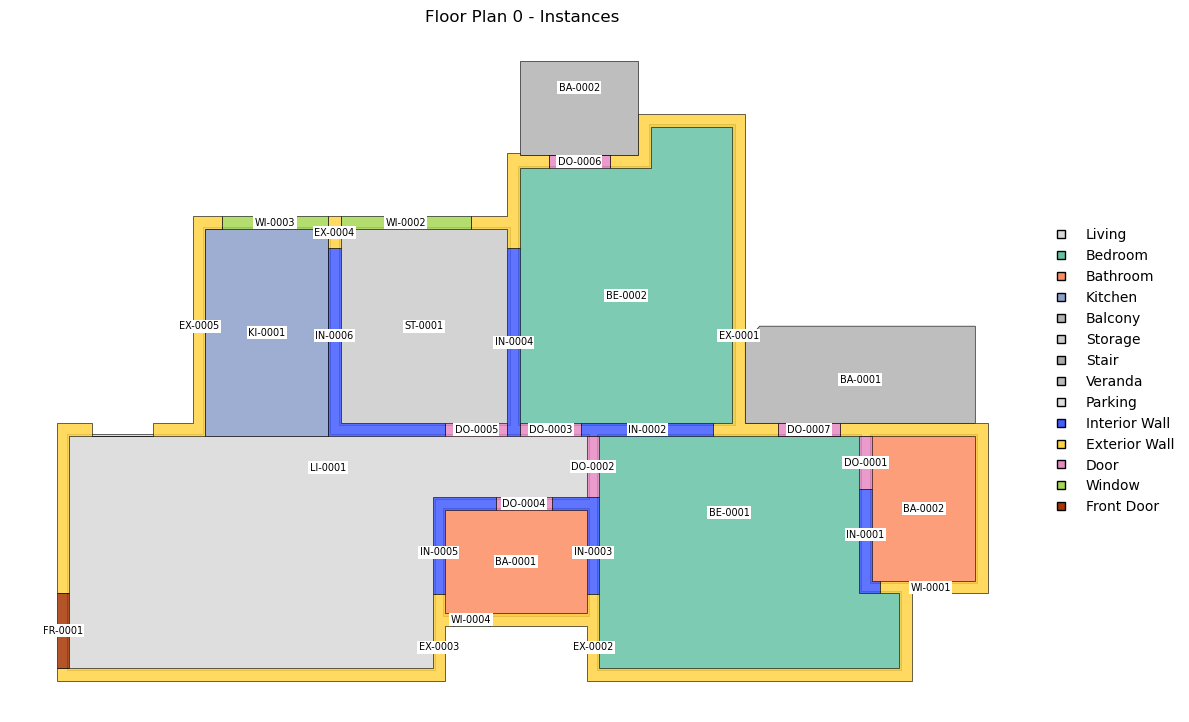

<Axes: title={'center': 'Floor Plan 0 - Instances'}>

In [15]:
# Run comprehensive sanity check
plot_floor_plan_instances(plan, title=f"Floor Plan {idx} - Instances", show_labels=True)

In [16]:
import json, os, math
from copy import deepcopy
from shapely.geometry import shape, Polygon, MultiPolygon, Point
from shapely.ops import unary_union

def _load(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def _save(obj, path):
    tmp = path + ".tmp"
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
    os.replace(tmp, path)

def _geom_of(obj):
    # handles objects that store geometry in "geom" like your export
    g = obj.get("geom")
    return shape(g) if isinstance(g, dict) and "type" in g else None

def _bbox_width_height(bbox):
    # bbox = [minx,miny,maxx,maxy] from your file; fallback via polygon bounds if missing
    minx, miny, maxx, maxy = bbox
    return abs(maxx-minx), abs(maxy-miny)

def _collect_instances(plan):
    inst = plan.get("instances", {})
    rooms = []
    for cat, arr in inst.get("room", {}).items():
        for r in arr:
            rr = deepcopy(r)
            rr["_room_type"] = cat
            rooms.append(rr)
    walls = []
    for cat in ("interior_wall","exterior_wall"):
        for w in inst.get("structural", {}).get(cat, []):
            ww = deepcopy(w)
            ww["_wall_type"] = cat
            walls.append(ww)
    doors = inst.get("structural", {}).get("door", [])
    front_doors = inst.get("structural", {}).get("front_door", [])
    return rooms, walls, doors, front_doors

def _lookup_maps(plan):
    """Build fast lookup dicts from your existing relations."""
    rel = plan.get("graph", {}).get("relations", {})
    bounded_by = rel.get("bounded_by", [])
    hosts = rel.get("hosts_opening", [])

    wall_to_rooms = {}
    for e in bounded_by:
        wall_to_rooms.setdefault(e["wall"], set()).add(e["room"])

    opening_to_walls = {}
    for e in hosts:
        opening_to_walls.setdefault(e["opening"], []).append(e["wall"])

    wall_type = {}
    inst_struct = plan.get("instances", {}).get("structural", {})
    for w in inst_struct.get("interior_wall", []):
        wall_type[w["id"]] = "interior_wall"
    for w in inst_struct.get("exterior_wall", []):
        wall_type[w["id"]] = "exterior_wall"

    # room type map
    room_type = {}
    for cat, arr in plan.get("instances", {}).get("room", {}).items():
        for r in arr:
            room_type[r["id"]] = cat

    # geometry maps
    room_geom = {}
    for cat, arr in plan.get("instances", {}).get("room", {}).items():
        for r in arr:
            room_geom[r["id"]] = _geom_of(r)
    door_geom, door_bbox = {}, {}
    for d in inst_struct.get("door", []):
        door_geom[d["id"]] = _geom_of(d)
        door_bbox[d["id"]] = d.get("props", {}).get("bbox")
    for d in inst_struct.get("front_door", []):
        door_geom[d["id"]] = _geom_of(d)
        door_bbox[d["id"]] = d.get("props", {}).get("bbox")

    opening_to_walls = opening_to_walls  # for return
    return wall_to_rooms, opening_to_walls, wall_type, room_type, room_geom, door_geom, door_bbox

In [17]:
from shapely.geometry import Point

def _nearest_two_rooms_on_wall(door_id, host_wall_ids, wall_to_rooms, room_geom, door_geom):
    """
    Input:
      - door_id: "DO-0002" etc.
      - host_wall_ids: 1..n wall ids hosting the door (duplicates exist in your file)
      - wall_to_rooms: dict wall -> set(rooms) from bounded_by
      - room_geom: dict room -> shapely polygon
      - door_geom: dict door -> shapely polygon
    Output: list of up to two room ids in priority order
    Strategy:
      1) union candidate rooms from all host walls
      2) compute distance from door centroid to each candidate room polygon
      3) pick the two closest distinct rooms
    """
    cand_rooms = set()
    for w in host_wall_ids:
        cand_rooms |= set(wall_to_rooms.get(w, []))
    cand_rooms = list(cand_rooms)
    if not cand_rooms:
        return []  # unknown

    dc = door_geom.get(door_id)
    if dc is None or dc.is_empty:
        # fallback: arbitrary two
        return cand_rooms[:2]

    c = dc.centroid
    scored = []
    for rid in cand_rooms:
        rg = room_geom.get(rid)
        if rg is None or rg.is_empty: 
            continue
        d = rg.distance(c)
        # if door centroid already inside room buffer, distance ~ 0
        scored.append((d, rid))
    scored.sort(key=lambda x: x[0])
    return [rid for _, rid in scored[:2]]

In [18]:
def _door_width(door_id, door_bbox):
    bb = door_bbox.get(door_id)
    if not bb: 
        return None
    w, h = _bbox_width_height(bb)
    # choose the smaller as thickness, larger as clear width proxy
    return max(w, h)

def build_connected_via_door(plan):
    rooms, walls, doors, front_doors = _collect_instances(plan)
    wall_to_rooms, opening_to_walls, wall_type, room_type, room_geom, door_geom, door_bbox = _lookup_maps(plan)

    passages = []
    used_ids = set()

    # iterate all doors (including front doors)
    all_doors = [{"id":d["id"], "kind":"door"} for d in doors] + [{"id":d["id"], "kind":"front_door"} for d in front_doors]

    for d in all_doors:
        did = d["id"]
        host_walls = opening_to_walls.get(did, [])
        if not host_walls:
            # no host wall recorded → skip, to be audited
            continue

        # disambiguate rooms on either side using centroid distance
        rooms_sorted = _nearest_two_rooms_on_wall(did, host_walls, wall_to_rooms, room_geom, door_geom)

        # if only one room is found and any host wall is exterior → connect to OUT-0000
        if len(rooms_sorted) == 1:
            is_exterior = any(wall_type.get(wid) == "exterior_wall" for wid in host_walls)
            target = "OUT-0000" if is_exterior else None
            if target:
                rids = [rooms_sorted[0], target]
            else:
                # cannot infer second room reliably; leave as single-sided connection
                rids = [rooms_sorted[0]]
        else:
            rids = rooms_sorted[:2]

        if not rids:
            continue

        # attributes
        width = _door_width(did, door_bbox)
        through_wall = host_walls[0]  # primary host (first as recorded); optional: choose exterior over interior for front_door
        if d["kind"] == "front_door":
            # prefer an exterior wall if present
            for wid in host_walls:
                if wall_type.get(wid) == "exterior_wall":
                    through_wall = wid
                    break

        # assemble record
        rec = {
            "id": f"E-pass-{len(passages)+1:05d}",
            "door": did,
            "door_type": d["kind"],
            "rooms": rids,
            "through_wall": through_wall,
            "width": width,
            "room_types": [room_type.get(r, "outside" if r=="OUT-0000" else None) for r in rids]
        }
        passages.append(rec)

    return passages

In [19]:
def refine_connected_via_door_inplace(json_path):
    plan = _load(json_path)

    # Ensure Outside virtual node exists (non-destructive)
    virt = plan.setdefault("instances", {}).setdefault("virtual", [])
    if not any(v.get("id") == "OUT-0000" for v in virt):
        virt.append({"id":"OUT-0000","class":"Outside","props":{"note":"virtual exterior"}})

    # Rebuild passages
    passages = build_connected_via_door(plan)

    # Write back under your existing container
    gr = plan.setdefault("graph", {})
    rel = gr.setdefault("relations", {})
    rel["connected_via_door"] = passages

    # Update summary counts to match your schema
    plan.setdefault("relationships", {}).setdefault("summary", {})
    plan["relationships"]["summary"]["door_connections"] = len(passages)

    _save(plan, json_path)
    return passages

In [20]:
path = "/Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Workspace2/ResPlan/resplan_json/plan_00000.json"  # adjust if you moved it

passages = refine_connected_via_door_inplace(path)
print("connected_via_door:", len(passages))
for p in passages:
    print(p["id"], p["door"], "→", p["rooms"], "| wall:", p["through_wall"], "| width:", p["width"], "| types:", p["room_types"])

connected_via_door: 8
E-pass-00001 DO-0001 → ['BE-0001', 'BA-0001'] | wall: IN-0001 | width: 14.849187935034806 | types: ['bedroom', 'balcony']
E-pass-00002 DO-0002 → ['LI-0001', 'BE-0001'] | wall: IN-0003 | width: 17.225058004640374 | types: ['living', 'bedroom']
E-pass-00003 DO-0003 → ['LI-0001', 'BE-0002'] | wall: IN-0004 | width: 17.22505800464036 | types: ['living', 'bedroom']
E-pass-00004 DO-0004 → ['LI-0001', 'BE-0001'] | wall: IN-0005 | width: 15.740139211136892 | types: ['living', 'bedroom']
E-pass-00005 DO-0005 → ['ST-0001', 'LI-0001'] | wall: IN-0006 | width: 17.522041763341065 | types: ['storage', 'living']
E-pass-00006 DO-0006 → ['BE-0002', 'BA-0002'] | wall: EX-0001 | width: 17.225058004640346 | types: ['bedroom', 'balcony']
E-pass-00007 DO-0007 → ['BE-0001', 'BA-0001'] | wall: EX-0001 | width: 17.225058004640346 | types: ['bedroom', 'balcony']
E-pass-00008 FR-0001 → ['LI-0001', 'KI-0001'] | wall: EX-0003 | width: 21.085846867749417 | types: ['living', 'kitchen']


In [21]:
import json, os

# 2) load → relabel → save
with open(path, "r", encoding="utf-8") as f:
    plan = json.load(f)

remap = relabel_rooms_with_subtype_prefixes_inplace(plan)

with open(path, "w", encoding="utf-8") as f:
    json.dump(plan, f, ensure_ascii=False, indent=2)

print("Renamed:", len(remap), "IDs")

Renamed: 7 IDs


## TEDS

In [28]:
def find_door_connections_simple(door_id, door_type, door_geom, room_geom_map):
    """
    Find rooms connected by a door using simple intersection logic.
    - Interior doors: connect exactly 2 rooms they touch
    - Front doors: connect 1 room + "OUT-0000"
    """
    connected_rooms = []
    
    # Find all rooms that intersect with the door
    for room_id, room_polygon in room_geom_map.items():
        if room_polygon and not room_polygon.is_empty:
            # Use small buffer for geometric tolerance
            if door_geom.buffer(0.01).intersects(room_polygon):
                connected_rooms.append(room_id)
    
    # Apply door type logic
    if door_type == "front_door":
        if len(connected_rooms) == 1:
            connected_rooms.append("OUT-0000")
        elif len(connected_rooms) == 0:
            connected_rooms = ["OUT-0000"]  # Only connects outside
        elif len(connected_rooms) > 1:
            # Keep first room + outside
            connected_rooms = [connected_rooms[0], "OUT-0000"]
            
    elif door_type == "door":
        # Interior doors should connect exactly 2 rooms
        if len(connected_rooms) != 2:
            print(f"WARNING: Interior door {door_id} connects {len(connected_rooms)} rooms - expected 2")
            # Keep first 2 if more than 2, or all if less than 2
    
    return connected_rooms[:2]  # Safety limit to 2 connections

def build_connected_via_door(plan):
    """
    Build door connections using simple intersection logic.
    """
    # Extract instances and geometry
    inst = plan.get("instances", {})
    rooms_by_type = inst.get("room", {})
    structural = inst.get("structural", {})
    
    # Build room geometry map
    room_geom = {}
    room_type_map = {}
    for subtype, arr in rooms_by_type.items():
        for r in arr:
            g = r.get("geom")
            if isinstance(g, dict) and "type" in g:
                room_geom[r["id"]] = shape(g)
                room_type_map[r["id"]] = subtype
    
    # Build door list and geometry map
    door_geom = {}
    door_bbox = {}
    all_doors = []
    
    for kind in ("door", "front_door"):
        for d in structural.get(kind, []):
            door_geom[d["id"]] = shape(d.get("geom"))
            door_bbox[d["id"]] = d.get("props", {}).get("bbox")
            all_doors.append({"id": d["id"], "kind": kind})
    
    # Build passages using simple intersection logic
    passages = []
    
    for d in all_doors:
        door_id = d["id"]
        door_type = d["kind"]
        
        dg = door_geom.get(door_id)
        if dg is None or dg.is_empty:
            continue
        
        # Find connected rooms using simple intersection
        connected_rooms = find_door_connections_simple(
            door_id, door_type, dg, room_geom
        )
        
        if not connected_rooms:
            print(f"WARNING: No connections found for door {door_id}")
            continue
        
        # Calculate door width from bbox
        width = None
        bb = door_bbox.get(door_id)
        if bb:
            minx, miny, maxx, maxy = bb
            width = max(abs(maxx - minx), abs(maxy - miny))
        
        # Get room types for connected rooms
        room_types = []
        for rid in connected_rooms:
            if rid == "OUT-0000":
                room_types.append("outside")
            else:
                room_types.append(room_type_map.get(rid, "unknown"))
        
        # Create passage record
        passages.append({
            "id": f"E-pass-{len(passages)+1:05d}",
            "door": door_id,
            "door_type": door_type,
            "rooms": connected_rooms,
            "width": width,
            "room_types": room_types
        })
    
    return passages

def refine_connected_via_door_inplace(json_path):
    """
    Update the JSON file with new door connections using simple intersection logic.
    """
    with open(json_path, "r", encoding="utf-8") as f:
        plan = json.load(f)
    
    # Ensure OUT-0000 virtual node exists
    virt = plan.setdefault("instances", {}).setdefault("virtual", [])
    if not any(v.get("id") == "OUT-0000" for v in virt):
        virt.append({"id": "OUT-0000", "class": "Outside", "props": {"note": "virtual exterior"}})
    
    # Build new connections
    passages = build_connected_via_door(plan)
    
    # Update in plan
    gr = plan.setdefault("graph", {})
    rel = gr.setdefault("relations", {})
    rel["connected_via_door"] = passages
    
    # Update summary
    plan.setdefault("relationships", {}).setdefault("summary", {})
    plan["relationships"]["summary"]["door_connections"] = len(passages)
    
    # Save back to file
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(plan, f, ensure_ascii=False, indent=2)
    
    return passages